In [1]:
#importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

In [6]:
df_us = df[df['job_country']== 'United States'].copy()

In [10]:
df_us['job_posted_month']= df_us['job_posted_date'].dt.strftime('%B')
df_us_pivot= df_us.pivot_table(index='job_posted_month', columns='job_title_short' ,aggfunc='size')
df_us_pivot = df_us_pivot.reset_index()
df_us_pivot['month_no']= pd.to_datetime(df_us_pivot['job_posted_month'], format= '%B').dt.month
df_us_pivot= df_us_pivot.sort_values('month_no')
df_us_pivot= df_us_pivot.set_index('job_posted_month')
df_us_pivot= df_us_pivot.drop(columns='month_no')
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [11]:
software_skils= pd.read_csv("http://lukeb.co/software_csv" , index_col='job_posted_month')

In [14]:
merged_data= pd.merge(df_us_pivot,software_skils, on='job_posted_month')

In [22]:
top_5= merged_data.sum().sort_values(ascending= False).head().index.to_list()

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

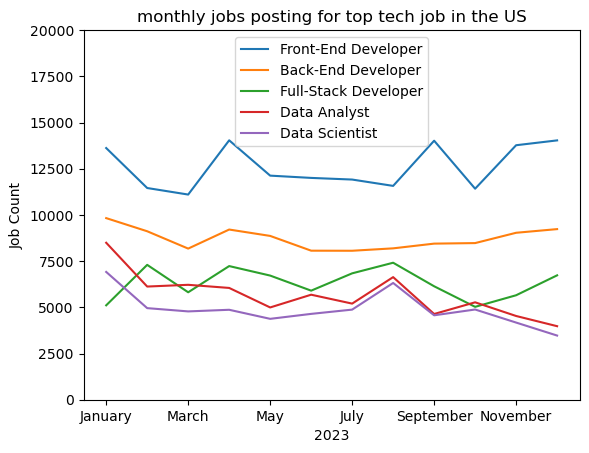

In [26]:
merged_data[top_5].plot(kind= 'line')
plt.title('monthly jobs posting for top tech job in the US')
plt.xlabel(2023)
plt.ylabel('Job Count')
plt.ylim(0,20000)
plt.legend()
plt.show()